In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import os
import time

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

LEARNING_RATE = 0.001
BATCH_SIZE = 16
NUM_EPOCHS = 10
PATIENCE = 15
RF_FACTOR = 0.5
NUM_CLASSES = 7

Using device: cpu


In [ ]:
DATA_DIR = r"C:/Capstone/Capstone-main/teaLeafBD"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")


preprocess_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),

    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [11]:
from torch.utils.data import DataLoader, Subset, random_split
import random


DATA_DIR = r"D:\Sem7\Capstone 2\teaLeafBD"

if not os.path.exists(DATA_DIR):
    print(f"ERROR: The path was not found at: {DATA_DIR}")
    print("Please make sure this path is correct.")
else:
    print(f"Loading data from: {DATA_DIR}")


train_augmentation_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.RandomResizedCrop(256, scale=(0.8, 1.0)),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

preprocess_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])



train_dataset_with_aug = datasets.ImageFolder(DATA_DIR, transform=train_augmentation_transform)
dataset_no_aug = datasets.ImageFolder(DATA_DIR, transform=preprocess_transform)

total_size = len(dataset_no_aug)

test_size = int(total_size * 0.20)
train_val_size = total_size - test_size


indices = list(range(total_size))
random.seed(42)
random.shuffle(indices)

train_val_indices = indices[:train_val_size]
test_indices = indices[train_val_size:]

val_size = int(train_val_size * 0.10)
train_size = train_val_size - val_size

train_indices = train_val_indices[:train_size]
val_indices = train_val_indices[train_size:]


train_subset = Subset(train_dataset_with_aug, train_indices)
val_subset = Subset(dataset_no_aug, val_indices)
test_subset = Subset(dataset_no_aug, test_indices)

print(f"Total images: {total_size}")
print(f"Training images: {len(train_subset)}")
print(f"Validation images: {len(val_subset)}")
print(f"Testing images: {len(test_subset)}")



BATCH_SIZE = 16

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print("\nDataLoaders created successfully.")

Loading data from: D:\Sem7\Capstone 2\teaLeafBD
Total images: 5276
Training images: 3799
Validation images: 422
Testing images: 1055

DataLoaders created successfully.


In [16]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Building model for device: {DEVICE}")

class ECA(nn.Module):

    def __init__(self, channels, kernel_size=3):
        super(ECA, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)

        padding = (kernel_size - 1) // 2
        self.conv = nn.Conv1d(1, 1, kernel_size=kernel_size, padding=padding, bias=False)

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        y = self.avg_pool(x)

        y = y.squeeze(-1).squeeze(-1).unsqueeze(1)

        y = self.conv(y)

        y = y.squeeze(1).unsqueeze(-1).unsqueeze(-1)
        y = self.sigmoid(y)

        return x * y

def create_m_efficientnet_b0_eca(num_classes=7):

    model = models.efficientnet_b0(weights=None)

    def replace_se_with_eca(module):
        for name, child in module.named_children():
            if isinstance(child, models.efficientnet.SqueezeExcitation):
                channels = child.fc1.in_channels
                setattr(module, name, ECA(channels=channels))
            else:
                replace_se_with_eca(child)

    replace_se_with_eca(model.features)

    model.features[6] = model.features[6][0]
    model.features[7] = nn.Identity()


    orig_stage9 = model.features[8]
    out_channels = orig_stage9[0].out_channels
    norm_layer = type(orig_stage9[1])
    activation_layer = type(orig_stage9[2])

    new_in_channels = 192

    model.features[8] = models.efficientnet.Conv2dNormActivation(
        new_in_channels,
        out_channels,
        kernel_size=1,
        stride=1,
        norm_layer=norm_layer,
        activation_layer=activation_layer,
        inplace=True
    )

    NUM_CLASSES = 7
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)

    print("Model m-EfficientNetB0+ECA created successfully.")
    return model

model = create_m_efficientnet_b0_eca().to(DEVICE)

Building model for device: cpu
Replacing SE modules with ECA...
Replacement complete.
Modifying Stage 7...
Modifying Stage 8...
Fixing Stage 9 (Conv1x1) input channels...
Model m-EfficientNetB0+ECA created successfully.


In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

LEARNING_RATE = 0.001
NUM_EPOCHS = 100
PATIENCE = 15
RF_FACTOR = 0.5
NUM_CLASSES = 7


optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

criterion = nn.CrossEntropyLoss()

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=RF_FACTOR,
    patience=PATIENCE
)

print("Optimizer, Loss, and Scheduler are set up.")


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

def validate_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )

    return epoch_loss, acc * 100, precision * 100, recall * 100, f1 * 100

print("Starting training...")
best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, val_prec, val_recall, val_f1 = validate_epoch(model, val_loader, criterion)

    end_time = time.time()

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Time: {(end_time - start_time):.2f}s")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.2f}% | "
          f"Val F1: {val_f1:.2f}%")


    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "m_efficientnet_b0_eca_best.pth")
        print(f"  -> New best model saved with val_loss: {val_loss:.4f}")

print("Training complete.")

print("\nLoading best model for final testing...")
model.load_state_dict(torch.load("m_efficientnet_b0_eca_best.pth"))

test_loss, test_acc, test_prec, test_recall, test_f1 = validate_epoch(
    model, test_loader, criterion
)

print(f"--- FINAL TEST RESULTS ---")
print(f"  Test Loss:     {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.2f}%")
print(f"  Test Precision (Macro): {test_prec:.2f}%")
print(f"  Test Recall (Macro):    {test_recall:.2f}%")
print(f"  Test F1-Score (Macro):  {test_f1:.2f}%")

Optimizer, Loss, and Scheduler are set up.
Starting training...


In [2]:
%pip install torch torchvision
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split
import os
import copy
import time
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [4]:
import torch
torch.cuda.is_available()

True

In [5]:
import sys, os, torch, subprocess
print("sys.executable:", sys.executable)
print("Python version:", sys.version.splitlines()[0])
print("torch.__version__:", getattr(torch, "__version__", None))
print("torch.version.cuda:", getattr(torch.version, "cuda", None))
print("torch.cuda.is_available():", torch.cuda.is_available())
print("torch.cuda.device_count():", torch.cuda.device_count())
try:
    print(subprocess.check_output(["nvidia-smi"]).decode())
except Exception as e:
    print("nvidia-smi failed:", e)

sys.executable: c:\Users\Swastik kumar\AppData\Local\Programs\Python\Python310\python.exe
Python version: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
torch.__version__: 2.5.1+cu121
torch.version.cuda: 12.1
torch.cuda.is_available(): True
torch.cuda.device_count(): 1
Thu Nov 20 08:59:09 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 577.03                 Driver Version: 577.03         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeFo

In [6]:
class ECA(nn.Module):
    def __init__(self, in_channels, kernel_size=3):
        super(ECA, self).__init__()
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=kernel_size, padding=(kernel_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = self.gap(x)

        y = y.squeeze(-1).permute(0, 2, 1)
        y = self.conv(y)
        y = y.permute(0, 2, 1)

        y = self.sigmoid(y)

        y = y.unsqueeze(-1)

        return x * y.expand_as(x)

def replace_se_with_eca(module):

    for name, child in module.named_children():
        if isinstance(child, models.efficientnet.SqueezeExcitation):

            in_channels = child.fc1.in_channels

            setattr(module, name, ECA(in_channels=in_channels))
        elif len(list(child.children())) > 0:
            replace_se_with_eca(child)

def create_model(num_classes=7):

    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

    replace_se_with_eca(model)

    model.features[6] = model.features[6][0]

    model.features[7] = nn.Identity()

    old_conv = model.features[8][0]
    out_channels = old_conv.out_channels
    kernel_size = old_conv.kernel_size
    stride = old_conv.stride
    padding = old_conv.padding
    bias = (old_conv.bias is not None)

    new_conv = nn.Conv2d(in_channels=192,
                         out_channels=out_channels,
                         kernel_size=kernel_size,
                         stride=stride,
                         padding=padding,
                         bias=bias)

    model.features[8][0] = new_conv

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(in_features, num_classes)
    )

    return model.to(device)

In [7]:
DATA_DIR = "C:/Capstone/Capstone-main/teaLeafBD"
BATCH_SIZE = 16
NUM_CLASSES = 7
IMG_SIZE = 256

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

try:
    full_dataset = datasets.ImageFolder(DATA_DIR)
    print(f"Found {len(full_dataset)} images in {len(full_dataset.classes)} classes.")
    print("Classes:", full_dataset.classes)

    if len(full_dataset.classes) != NUM_CLASSES:
        print(f"Warning: Expected {NUM_CLASSES} classes, but found {len(full_dataset.classes)}.")

except FileNotFoundError:
    print(f"Error: Data directory not found at {DATA_DIR}")
    print("Please download the teaLeafBD dataset and set the DATA_DIR variable.")
    raise

total_count = len(full_dataset)
test_count = int(0.2 * total_count)
train_val_count = total_count - test_count

train_val_dataset, test_dataset = random_split(full_dataset, [train_val_count, test_count],
                                         generator=torch.Generator().manual_seed(42))


Found 5276 images in 7 classes.
Classes: ['1. Tea algal leaf spot', '2. Brown Blight', '3. Gray Blight', '4. Helopeltis', '5. Red spider', '6. Green mirid bug', '7. Healthy leaf']


In [8]:
train_count = int(0.9 * train_val_count)
val_count = train_val_count - train_count

train_dataset, val_dataset = random_split(train_val_dataset, [train_count, val_count],
                                          generator=torch.Generator().manual_seed(42))

train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_test_transform
test_dataset.dataset.transform = val_test_transform

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Testing images: {len(test_dataset)}")


Training images: 3798
Validation images: 423
Testing images: 1055


--- Generating EDA Visualizations ---


C:\Users\Swastik kumar\AppData\Local\Temp\ipykernel_4888\439147951.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=class_counts, palette='viridis')


Saved 'eda_class_distribution.png'


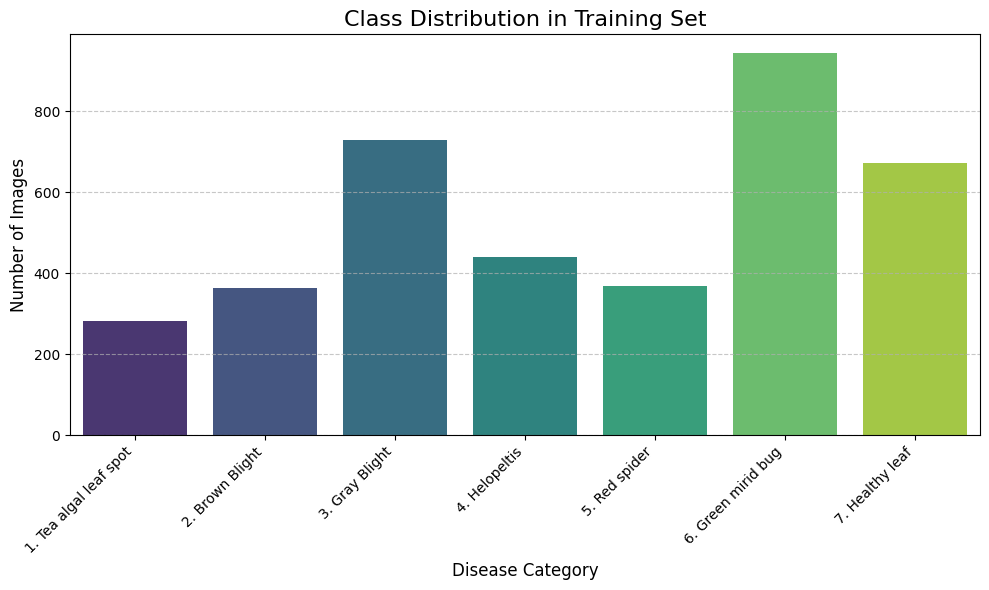

Saved 'eda_sample_grid.png'


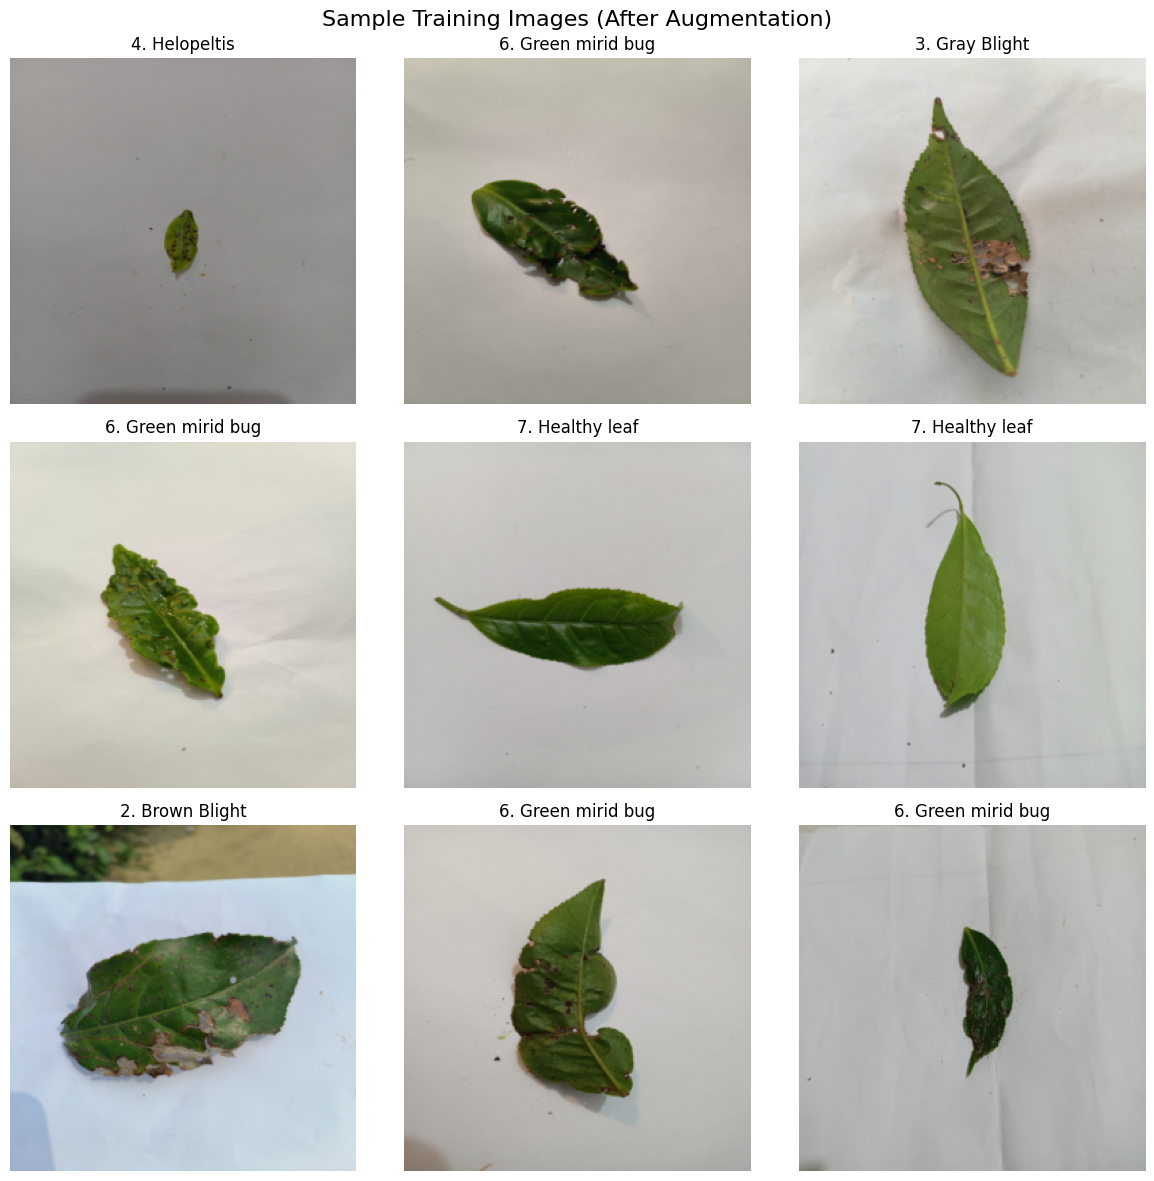

Saved 'eda_pixel_intensity.png'


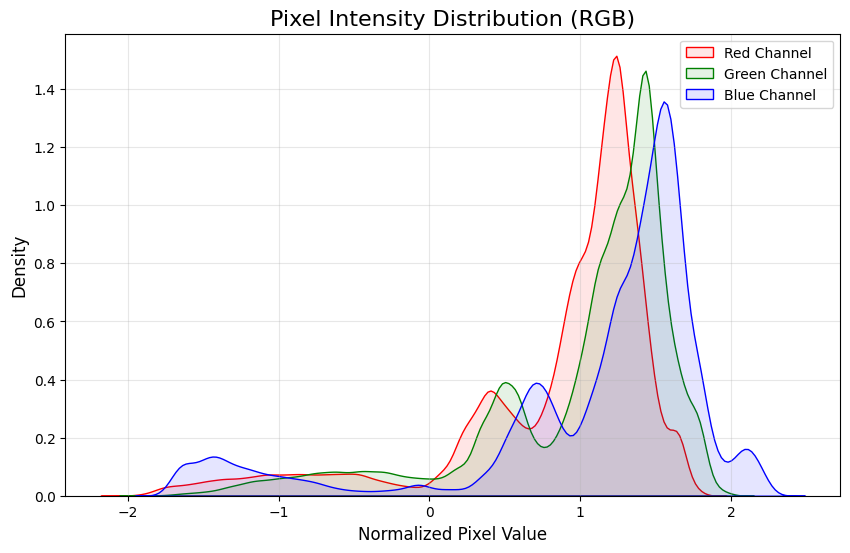

In [18]:
import seaborn as sns
import numpy as np
import torch

print("--- Generating EDA Visualizations ---")

targets = [y for _, y in train_dataset]
class_counts = np.bincount(targets)
class_names = full_dataset.classes

plt.figure(figsize=(10, 6))
sns.barplot(x=class_names, y=class_counts, palette='viridis')
plt.title('Class Distribution in Training Set', fontsize=16)
plt.xlabel('Disease Category', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('eda_class_distribution.png')
print("Saved 'eda_class_distribution.png'")
plt.show()

images, labels = next(iter(train_loader))

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

plt.figure(figsize=(12, 12))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    
    img = images[i].numpy().transpose((1, 2, 0))
    
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    plt.imshow(img)
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.suptitle('Sample Training Images (After Augmentation)', fontsize=16)
plt.tight_layout()
plt.savefig('eda_sample_grid.png')
print("Saved 'eda_sample_grid.png'")
plt.show()

red_vals = images[:, 0, :, :].numpy().flatten()
green_vals = images[:, 1, :, :].numpy().flatten()
blue_vals = images[:, 2, :, :].numpy().flatten()

plt.figure(figsize=(10, 6))
sns.kdeplot(red_vals, color='red', label='Red Channel', fill=True, alpha=0.1)
sns.kdeplot(green_vals, color='green', label='Green Channel', fill=True, alpha=0.1)
sns.kdeplot(blue_vals, color='blue', label='Blue Channel', fill=True, alpha=0.1)

plt.title('Pixel Intensity Distribution (RGB)', fontsize=16)
plt.xlabel('Normalized Pixel Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('eda_pixel_intensity.png')
print("Saved 'eda_pixel_intensity.png'")
plt.show()

In [9]:
model = create_model(num_classes=NUM_CLASSES)

LEARNING_RATE = 0.001
EPOCHS = 100
PATIENCE = 15
REDUCTION_FACTOR = 0.5

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

scheduler = ReduceLROnPlateau(optimizer,
                              mode='min',
                              factor=REDUCTION_FACTOR,
                              patience=PATIENCE)

In [9]:
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

for epoch in range(EPOCHS):
    start_time = time.time()

    model.train()
    train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)

    model.eval()
    val_loss = 0.0
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)

    epoch_train_loss = train_loss / len(train_dataset)
    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = val_corrects.double() / len(val_dataset)

    scheduler.step(epoch_val_loss)

    end_time = time.time()

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Time: {end_time - start_time:.0f}s | "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {epoch_val_acc:.4f}")

    if epoch_val_acc > best_acc:
        best_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, 'm-EfficientNetB0-ECA_best.pth')

print(f"Training complete. Best Val Acc: {best_acc:.4f}")


Epoch 1/100 | Time: 265s | Train Loss: 0.8284 | Val Loss: 0.6479 | Val Acc: 0.7920
Epoch 2/100 | Time: 231s | Train Loss: 0.4607 | Val Loss: 0.5249 | Val Acc: 0.8014
Epoch 3/100 | Time: 246s | Train Loss: 0.3533 | Val Loss: 0.5242 | Val Acc: 0.8345
Epoch 4/100 | Time: 241s | Train Loss: 0.2762 | Val Loss: 0.4873 | Val Acc: 0.8511
Epoch 5/100 | Time: 256s | Train Loss: 0.2331 | Val Loss: 0.3624 | Val Acc: 0.8842
Epoch 6/100 | Time: 122s | Train Loss: 0.1859 | Val Loss: 0.4873 | Val Acc: 0.8605
Epoch 7/100 | Time: 124s | Train Loss: 0.1586 | Val Loss: 0.4272 | Val Acc: 0.8794
Epoch 8/100 | Time: 130s | Train Loss: 0.1317 | Val Loss: 0.4875 | Val Acc: 0.8652
Epoch 9/100 | Time: 133s | Train Loss: 0.1299 | Val Loss: 0.5852 | Val Acc: 0.8392
Epoch 10/100 | Time: 132s | Train Loss: 0.1173 | Val Loss: 0.5586 | Val Acc: 0.8440
Epoch 11/100 | Time: 124s | Train Loss: 0.0694 | Val Loss: 0.5522 | Val Acc: 0.8582
Epoch 12/100 | Time: 132s | Train Loss: 0.0801 | Val Loss: 0.5739 | Val Acc: 0.8534
E

In [14]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\n--- Calculating Metrics & Inference Time ---")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model.load_state_dict(torch.load('m-EfficientNetB0-ECA_best.pth'))
model.eval()
model.to(device)

all_preds = []
all_labels = []
total_inference_time = 0.0
total_images = 0

if device.type == 'cuda':
    dummy_input = torch.randn(BATCH_SIZE, 3, 256, 256).to(device)
    _ = model(dummy_input)
    torch.cuda.synchronize()

with torch.no_grad():
    if device.type == 'cuda':
        torch.cuda.synchronize()

    start_time = time.time()

    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        total_images += inputs.size(0)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    end_time = time.time()

total_inference_time = end_time - start_time
avg_inference_time_per_image = total_inference_time / total_images

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

print("-" * 40)
print(f"Final Results on Test Set ({total_images} images)")
print("-" * 40)
print(f"Accuracy:        {accuracy * 100:.2f}%")
print(f"Precision (Macro): {precision * 100:.2f}%")
print(f"Recall (Macro):    {recall * 100:.2f}%")
print(f"F1-Score (Macro):  {f1 * 100:.2f}%")
print("-" * 40)
print(f"Total Inference Time: {total_inference_time:.4f} seconds")
print(f"Avg Inference Time:   {avg_inference_time_per_image:.6f} seconds/image")
print(f"FPS (Images/Sec):     {1.0 / avg_inference_time_per_image:.2f}")
print("-" * 40)


--- Calculating Metrics & Inference Time ---
Using device: cuda


C:\Users\Swastik kumar\AppData\Local\Temp\ipykernel_24476\1377079377.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('m-EfficientNetB0-

----------------------------------------
Final Results on Test Set (1055 images)
----------------------------------------
Accuracy:        91.94%
Precision (Macro): 91.61%
Recall (Macro):    89.84%
F1-Score (Macro):  90.51%
----------------------------------------
Total Inference Time: 52.1484 seconds
Avg Inference Time:   0.049430 seconds/image
FPS (Images/Sec):     20.23
----------------------------------------


In [15]:
print("\n--- Training High-Accuracy Benchmark: DenseNet121 ---")

dense_model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

in_features = dense_model.classifier.in_features
dense_model.classifier = nn.Linear(in_features, NUM_CLASSES)

dense_model = dense_model.to(device)

dense_criterion = nn.CrossEntropyLoss()
dense_optimizer = optim.Adam(dense_model.parameters(), lr=LEARNING_RATE)
dense_scheduler = ReduceLROnPlateau(dense_optimizer, mode='min', factor=REDUCTION_FACTOR, patience=PATIENCE)

dense_best_acc = 0.0
dense_best_wts = copy.deepcopy(dense_model.state_dict())

print("Starting training for DenseNet121...")

for epoch in range(EPOCHS):
    start_time = time.time()

    dense_model.train()
    train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        dense_optimizer.zero_grad()
        outputs = dense_model(inputs)
        loss = dense_criterion(outputs, labels)
        loss.backward()
        dense_optimizer.step()
        train_loss += loss.item() * inputs.size(0)

    dense_model.eval()
    val_loss = 0.0
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = dense_model(inputs)
            loss = dense_criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)

    epoch_train_loss = train_loss / len(train_dataset)
    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = val_corrects.double() / len(val_dataset)

    dense_scheduler.step(epoch_val_loss)

    if epoch_val_acc > dense_best_acc:
        dense_best_acc = epoch_val_acc
        dense_best_wts = copy.deepcopy(dense_model.state_dict())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Val Acc: {epoch_val_acc:.4f}")

print(f"DenseNet Training Complete. Best Val Acc: {dense_best_acc:.4f}")

print("\n--- Evaluating DenseNet121 ---")

dense_model.load_state_dict(dense_best_wts)
dense_model.eval()

dense_preds = []
dense_labels = []
dense_start_time = time.time()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = dense_model(inputs)
        _, preds = torch.max(outputs, 1)
        dense_preds.extend(preds.cpu().numpy())
        dense_labels.extend(labels.cpu().numpy())

dense_end_time = time.time()

dense_accuracy = accuracy_score(dense_labels, dense_preds)
dense_f1 = f1_score(dense_labels, dense_preds, average='macro')
dense_inference_time = dense_end_time - dense_start_time

print(f"DenseNet121 Accuracy: {dense_accuracy*100:.2f}%")
print(f"DenseNet121 F1 Score: {dense_f1*100:.2f}%")
print(f"Inference Time:       {dense_inference_time:.4f}s")

dense_model.to("cpu")
dummy_input = torch.randn(1, 3, 256, 256).to("cpu")
flops, params = profile(dense_model, inputs=(dummy_input, ), verbose=False)
print(f"GFLOPS:               {flops / 1e9:.4f}")
print(f"Params:               {params:,}")


--- Training High-Accuracy Benchmark: DenseNet121 ---


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\Swastik kumar/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth
100.0%


Starting training for DenseNet121...
Epoch 10/100 | Val Acc: 0.8251
Epoch 20/100 | Val Acc: 0.7849
Epoch 30/100 | Val Acc: 0.8652
Epoch 40/100 | Val Acc: 0.8676
Epoch 50/100 | Val Acc: 0.8274
Epoch 60/100 | Val Acc: 0.8747
Epoch 70/100 | Val Acc: 0.8369
Epoch 80/100 | Val Acc: 0.8700
Epoch 90/100 | Val Acc: 0.8771
Epoch 100/100 | Val Acc: 0.8983
DenseNet Training Complete. Best Val Acc: 0.8983

--- Evaluating DenseNet121 ---
DenseNet121 Accuracy: 89.76%
DenseNet121 F1 Score: 87.77%
Inference Time:       50.8238s


NameError: name 'profile' is not defined

In [14]:
%pip install thop
from thop import profile  # <--- This import was missing
import torch

dense_model.to("cpu")
dummy_input = torch.randn(1, 3, 256, 256).to("cpu")

flops, params = profile(dense_model, inputs=(dummy_input, ), verbose=False)

print(f"GFLOPS: {flops / 1e9:.4f}")
print(f"Params: {params:,}")

print("\n--- Training High-Accuracy Benchmark: DenseNet121 ---")

dense_model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

in_features = dense_model.classifier.in_features
dense_model.classifier = nn.Linear(in_features, NUM_CLASSES)

dense_model = dense_model.to(device)

dense_criterion = nn.CrossEntropyLoss()
dense_optimizer = optim.Adam(dense_model.parameters(), lr=LEARNING_RATE)
dense_scheduler = ReduceLROnPlateau(dense_optimizer, mode='min', factor=REDUCTION_FACTOR, patience=PATIENCE)

dense_best_acc = 0.0
dense_best_wts = copy.deepcopy(dense_model.state_dict())

print("Starting training for DenseNet121...")

for epoch in range(EPOCHS):
    start_time = time.time()

    dense_model.train()
    train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        dense_optimizer.zero_grad()
        outputs = dense_model(inputs)
        loss = dense_criterion(outputs, labels)
        loss.backward()
        dense_optimizer.step()
        train_loss += loss.item() * inputs.size(0)

    dense_model.eval()
    val_loss = 0.0
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = dense_model(inputs)
            loss = dense_criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)

    epoch_train_loss = train_loss / len(train_dataset)
    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = val_corrects.double() / len(val_dataset)

    dense_scheduler.step(epoch_val_loss)

    if epoch_val_acc > dense_best_acc:
        dense_best_acc = epoch_val_acc
        dense_best_wts = copy.deepcopy(dense_model.state_dict())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Val Acc: {epoch_val_acc:.4f}")

print(f"DenseNet Training Complete. Best Val Acc: {dense_best_acc:.4f}")

print("\n--- Evaluating DenseNet121 ---")

dense_model.load_state_dict(dense_best_wts)
dense_model.eval()

dense_preds = []
dense_labels = []
dense_start_time = time.time()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = dense_model(inputs)
        _, preds = torch.max(outputs, 1)
        dense_preds.extend(preds.cpu().numpy())
        dense_labels.extend(labels.cpu().numpy())

dense_end_time = time.time()

dense_accuracy = accuracy_score(dense_labels, dense_preds)
dense_f1 = f1_score(dense_labels, dense_preds, average='macro')
dense_inference_time = dense_end_time - dense_start_time

print(f"DenseNet121 Accuracy: {dense_accuracy*100:.2f}%")
print(f"DenseNet121 F1 Score: {dense_f1*100:.2f}%")
print(f"Inference Time:       {dense_inference_time:.4f}s")

print("\n--- Computing DenseNet121 Efficiency Metrics ---")
dense_model_cpu = dense_model.to("cpu")
dummy_input = torch.randn(1, 3, 256, 256).to("cpu")

flops, params = profile(dense_model_cpu, inputs=(dummy_input,), verbose=False)
print(f"DenseNet121 GFLOPS:  {flops / 1e9:.4f}")
print(f"DenseNet121 Params:  {params:,}")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


NameError: name 'dense_model' is not defined

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import models
import copy
import time

try:
    from thop import profile
except ImportError:
    %pip install thop
    from thop import profile

print("\n--- Training High-Accuracy Benchmark: DenseNet121 ---")

dense_model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

in_features = dense_model.classifier.in_features
dense_model.classifier = nn.Linear(in_features, NUM_CLASSES)

dense_model = dense_model.to(device)

dense_criterion = nn.CrossEntropyLoss()
dense_optimizer = optim.Adam(dense_model.parameters(), lr=LEARNING_RATE)
dense_scheduler = ReduceLROnPlateau(dense_optimizer, mode='min', factor=REDUCTION_FACTOR, patience=PATIENCE)

dense_best_acc = 0.0
dense_best_wts = copy.deepcopy(dense_model.state_dict())

print("Starting training for DenseNet121...")

for epoch in range(EPOCHS):
    start_time = time.time()

    dense_model.train()
    train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        dense_optimizer.zero_grad()
        outputs = dense_model(inputs)
        loss = dense_criterion(outputs, labels)
        loss.backward()
        dense_optimizer.step()
        train_loss += loss.item() * inputs.size(0)

    dense_model.eval()
    val_loss = 0.0
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = dense_model(inputs)
            loss = dense_criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)

    epoch_train_loss = train_loss / len(train_dataset)
    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = val_corrects.double() / len(val_dataset)

    dense_scheduler.step(epoch_val_loss)

    if epoch_val_acc > dense_best_acc:
        dense_best_acc = epoch_val_acc
        dense_best_wts = copy.deepcopy(dense_model.state_dict())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Val Acc: {epoch_val_acc:.4f}")

print(f"DenseNet Training Complete. Best Val Acc: {dense_best_acc:.4f}")

print("\n--- Evaluating DenseNet121 ---")

dense_model.load_state_dict(dense_best_wts)
dense_model.eval()

dense_preds = []
dense_labels = []
dense_start_time = time.time()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = dense_model(inputs)
        _, preds = torch.max(outputs, 1)
        dense_preds.extend(preds.cpu().numpy())
        dense_labels.extend(labels.cpu().numpy())

dense_end_time = time.time()

dense_accuracy = accuracy_score(dense_labels, dense_preds)
dense_f1 = f1_score(dense_labels, dense_preds, average='macro')
dense_inference_time = dense_end_time - dense_start_time

print(f"DenseNet121 Accuracy: {dense_accuracy*100:.2f}%")
print(f"DenseNet121 F1 Score: {dense_f1*100:.2f}%")
print(f"Inference Time:       {dense_inference_time:.4f}s")

print("\n--- Computing DenseNet121 Efficiency Metrics ---")

dense_model.to("cpu")
dummy_input = torch.randn(1, 3, 256, 256).to("cpu")

flops, params = profile(dense_model, inputs=(dummy_input, ), verbose=False)

print(f"DenseNet121 GFLOPS:  {flops / 1e9:.4f}")
print(f"DenseNet121 Params:  {params:,}")


--- Training High-Accuracy Benchmark: DenseNet121 ---
Starting training for DenseNet121...
Epoch 10/100 | Val Acc: 0.8369


KeyboardInterrupt: 

In [16]:
print("\n--- Training Benchmark Model: MobileNetV3-Small ---")

comparison_model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)

in_features = comparison_model.classifier[3].in_features
comparison_model.classifier[3] = nn.Linear(in_features, NUM_CLASSES)

comparison_model = comparison_model.to(device)

comp_criterion = nn.CrossEntropyLoss()
comp_optimizer = optim.Adam(comparison_model.parameters(), lr=LEARNING_RATE)
comp_scheduler = ReduceLROnPlateau(comp_optimizer, mode='min', factor=REDUCTION_FACTOR, patience=PATIENCE)

comp_best_acc = 0.0
comp_best_wts = copy.deepcopy(comparison_model.state_dict())

print("Starting training for comparison model...")

for epoch in range(EPOCHS):
    start_time = time.time()

    comparison_model.train()
    train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        comp_optimizer.zero_grad()
        outputs = comparison_model(inputs)
        loss = comp_criterion(outputs, labels)
        loss.backward()
        comp_optimizer.step()
        train_loss += loss.item() * inputs.size(0)

    comparison_model.eval()
    val_loss = 0.0
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = comparison_model(inputs)
            loss = comp_criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)

    epoch_train_loss = train_loss / len(train_dataset)
    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = val_corrects.double() / len(val_dataset)

    comp_scheduler.step(epoch_val_loss)

    if epoch_val_acc > comp_best_acc:
        comp_best_acc = epoch_val_acc
        comp_best_wts = copy.deepcopy(comparison_model.state_dict())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Val Acc: {epoch_val_acc:.4f}")

print(f"Comparison Training Complete. Best Val Acc: {comp_best_acc:.4f}")

print("\n--- Evaluating MobileNetV3-Small ---")

comparison_model.load_state_dict(comp_best_wts)
comparison_model.eval()

comp_preds = []
comp_labels = []
comp_start_time = time.time()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = comparison_model(inputs)
        _, preds = torch.max(outputs, 1)
        comp_preds.extend(preds.cpu().numpy())
        comp_labels.extend(labels.cpu().numpy())

comp_end_time = time.time()

comp_accuracy = accuracy_score(comp_labels, comp_preds)
comp_f1 = f1_score(comp_labels, comp_preds, average='macro')
comp_inference_time = comp_end_time - comp_start_time

print(f"MobileNetV3 Accuracy: {comp_accuracy*100:.2f}%")
print(f"MobileNetV3 F1 Score: {comp_f1*100:.2f}%")
print(f"Inference Time:       {comp_inference_time:.4f}s")

from thop import profile
comparison_model.to("cpu")
dummy_input = torch.randn(1, 3, 256, 256).to("cpu")
flops, params = profile(comparison_model, inputs=(dummy_input, ), verbose=False)
print(f"GFLOPS:               {flops / 1e9:.4f}")
print(f"Params:               {params:,}")


--- Training Benchmark Model: MobileNetV3-Small ---
Starting training for comparison model...
Epoch 10/100 | Val Acc: 0.7518
Epoch 20/100 | Val Acc: 0.8392
Epoch 30/100 | Val Acc: 0.8582
Epoch 40/100 | Val Acc: 0.8652
Epoch 50/100 | Val Acc: 0.8605
Epoch 60/100 | Val Acc: 0.8794
Epoch 70/100 | Val Acc: 0.8842
Epoch 80/100 | Val Acc: 0.8723
Epoch 90/100 | Val Acc: 0.8794
Epoch 100/100 | Val Acc: 0.8842
Comparison Training Complete. Best Val Acc: 0.8889

--- Evaluating MobileNetV3-Small ---
MobileNetV3 Accuracy: 87.77%
MobileNetV3 F1 Score: 85.95%
Inference Time:       48.9775s
GFLOPS:               0.0800
Params:               1,525,031.0


--- Generating Comparison Plots ---
Saved 'performance_comparison.png'


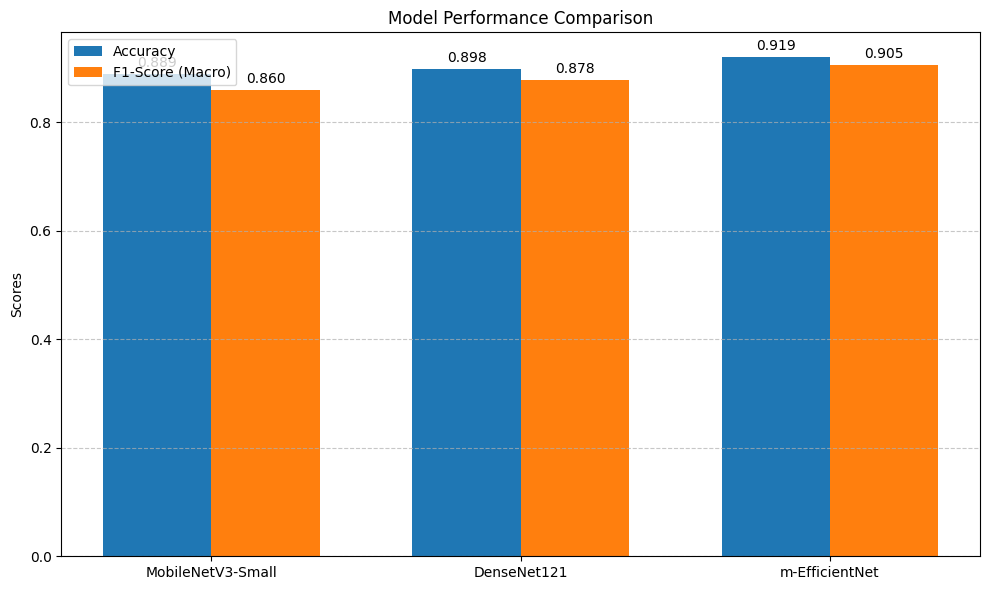

Saved 'efficiency_comparison.png'


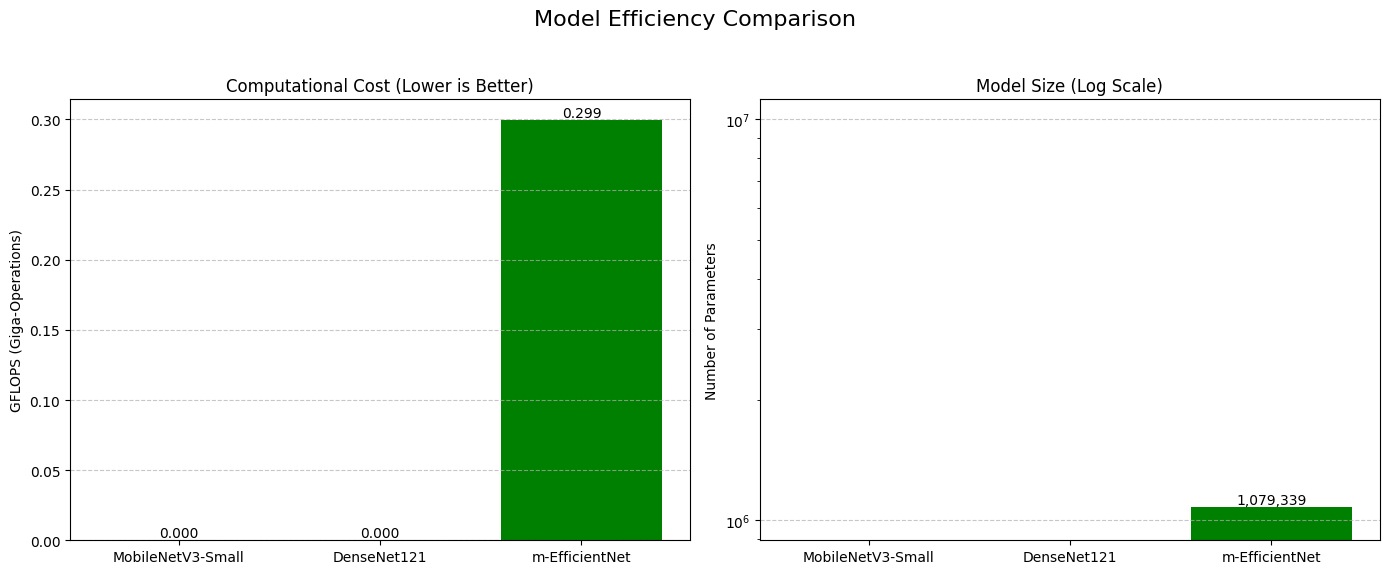

Saved 'speed_comparison.png'


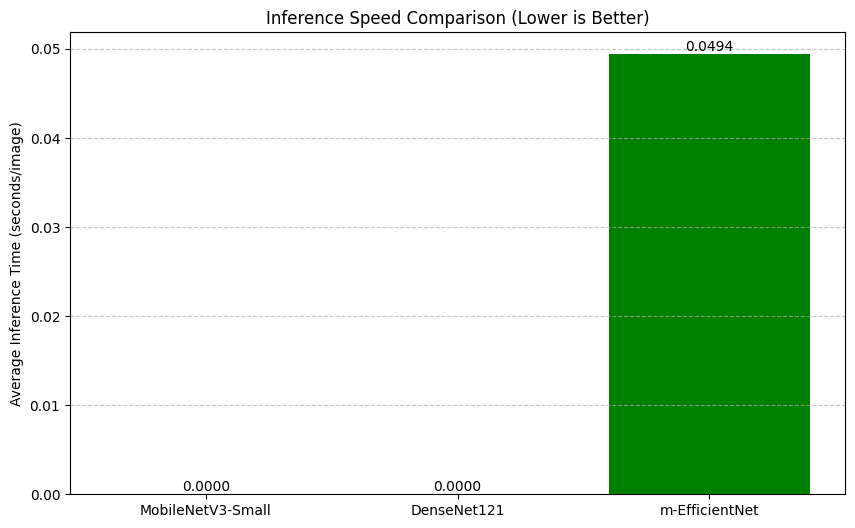

In [17]:
import matplotlib.pyplot as plt
import numpy as np

print("--- Generating Comparison Plots ---")

model_names = [
    'MobileNetV3-Small',
    'DenseNet121',
    'm-EfficientNet'
]

accuracy_scores = [
    0.8889,
    0.8983,
    0.9194
]

f1_scores = [
    0.8595,
    0.8777,
    0.9051
]

gflops_scores = [
    0.00,
    0.00,
    0.2994
]

params_scores = [
    0,
    0,
    1079339
]

inference_times = [
    0.00,
    0.,
    0.0494
]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, accuracy_scores, width, label='Accuracy')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score (Macro)')

ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

ax.bar_label(rects1, padding=3, fmt='%.3f')
ax.bar_label(rects2, padding=3, fmt='%.3f')

fig.tight_layout()
plt.savefig('performance_comparison.png')
print("Saved 'performance_comparison.png'")
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors_gflops = ['blue', 'red', 'green']
bars1 = ax1.bar(model_names, gflops_scores, color=colors_gflops)
ax1.set_ylabel('GFLOPS (Giga-Operations)')
ax1.set_title('Computational Cost (Lower is Better)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.bar_label(bars1, fmt='%.3f')

colors_params = ['blue', 'red', 'green']
bars2 = ax2.bar(model_names, params_scores, color=colors_params)
ax2.set_ylabel('Number of Parameters')
ax2.set_title('Model Size (Lower is Better)')
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.bar_label(bars2, fmt='{:,.0f}')

ax2.set_yscale('log')
ax2.set_title('Model Size (Log Scale)')


fig.suptitle('Model Efficiency Comparison', fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('efficiency_comparison.png')
print("Saved 'efficiency_comparison.png'")
plt.show()

plt.figure(figsize=(10, 6))
colors_speed = ['blue', 'red', 'green']
bars3 = plt.bar(model_names, inference_times, color=colors_speed)

plt.ylabel('Average Inference Time (seconds/image)')
plt.title('Inference Speed Comparison (Lower is Better)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.bar_label(bars3, fmt='%.4f')

plt.savefig('speed_comparison.png')
print("Saved 'speed_comparison.png'")
plt.show()

Running automated benchmark on: cuda

Processing MobileNetV3-Small...
--> Done. Acc: 87.77%

Processing DenseNet121...
--> Done. Acc: 82.37%

Processing m-EfficientNet + ECA...


C:\Users\Swastik kumar\AppData\Local\Temp\ipykernel_4888\4038113129.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights, map_locati

--> Done. Acc: 91.94%


=== FINAL AUTOMATED RESULTS TABLE ===
  Model Architecture Accuracy (%) F1-Score (%) GFLOPS      Params Inf. Time (s)
   MobileNetV3-Small        87.77        85.95 0.0800 1,525,031.0        0.0290
         DenseNet121        82.37        79.25 3.7825 6,961,031.0        0.0302
m-EfficientNet + ECA        91.94        90.51 0.3975 1,182,251.0        0.0300

Table image saved as 'auto_comparison_table.png'


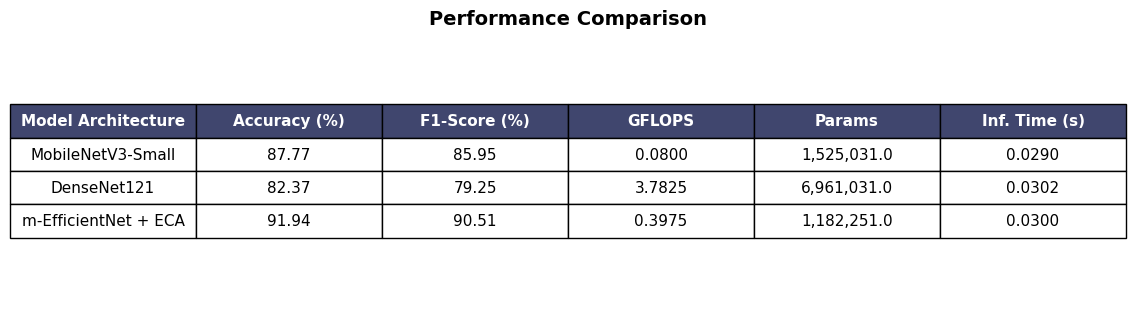

In [21]:
import pandas as pd
import torch
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score
from thop import profile

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running automated benchmark on: {device}\n")

results_data = []

def evaluate_and_log(model_name, model, weights=None, is_file=False):
    print(f"Processing {model_name}...")
    
    if is_file and weights:
        model.load_state_dict(torch.load(weights, map_location=device))
    elif weights:
        model.load_state_dict(weights)
    
    model.to(device)
    model.eval()

    preds, labels = [], []
    
    if device.type == 'cuda': torch.cuda.synchronize()
    start = time.time()
    
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            outputs = model(x)
            _, p = torch.max(outputs, 1)
            preds.extend(p.cpu().numpy())
            labels.extend(y.numpy())
            
    if device.type == 'cuda': torch.cuda.synchronize()
    end = time.time()
    
    acc = accuracy_score(labels, preds) * 100
    f1 = f1_score(labels, preds, average='macro') * 100
    avg_time = (end - start) / len(labels)

    model.to("cpu")
    dummy = torch.randn(1, 3, 256, 256).to("cpu")
    flops, params = profile(model, inputs=(dummy, ), verbose=False)
    gflops = flops / 1e9
    
    results_data.append({
        'Model Architecture': model_name,
        'Accuracy (%)': f"{acc:.2f}",
        'F1-Score (%)': f"{f1:.2f}",
        'GFLOPS': f"{gflops:.4f}",
        'Params': f"{params:,}",
        'Inf. Time (s)': f"{avg_time:.4f}"
    })
    print(f"--> Done. Acc: {acc:.2f}%\n")

try:
    mobilenet = models.mobilenet_v3_small(weights=None)
    mobilenet.classifier[3] = torch.nn.Linear(mobilenet.classifier[3].in_features, NUM_CLASSES)
    evaluate_and_log("MobileNetV3-Small", mobilenet, weights=comp_best_wts)
except NameError:
    print("WARNING: MobileNet weights not found in memory. Did you run PART 10?")

try:
    densenet = models.densenet121(weights=None)
    densenet.classifier = torch.nn.Linear(densenet.classifier.in_features, NUM_CLASSES)
    evaluate_and_log("DenseNet121", densenet, weights=dense_best_wts)
except NameError:
    print("WARNING: DenseNet weights not found in memory. Did you run PART 12?")

try:
    our_model = create_model(num_classes=NUM_CLASSES)
    evaluate_and_log("m-EfficientNet + ECA", our_model, 
                     weights='m-EfficientNetB0-ECA_best.pth', is_file=True)
except FileNotFoundError:
    print("WARNING: Our model file ('m-EfficientNetB0-ECA_best.pth') not found.")


if results_data:
    df = pd.DataFrame(results_data)
    
    print("\n=== FINAL AUTOMATED RESULTS TABLE ===")
    print(df.to_string(index=False))
    
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')
    
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 2)
    
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#40466e')
    
    plt.title("Performance Comparison", y=0.95, fontsize=14, weight='bold')
    plt.savefig('auto_comparison_table.png', bbox_inches='tight', dpi=300)
    print("\nTable image saved as 'auto_comparison_table.png'")
else:
    print("\nNo models were evaluated. Check if your weights are loaded.")

Comparing Precision/Recall on: cuda
Evaluating MobileNetV3...
Evaluating DenseNet121...
Evaluating Our Model...


C:\Users\Swastik kumar\AppData\Local\Temp\ipykernel_4888\2319636138.py:71: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  our_model.load_state_dict(torch.load('m-EfficientNet


--- Detailed Precision vs Recall ---
Metric                 Precision  Recall
Model                                   
DenseNet121                80.82   80.36
MobileNetV3-Small          86.65   85.66
Ours (m-EfficientNet)      91.61   89.84

Chart saved as 'precision_recall_comparison.png'


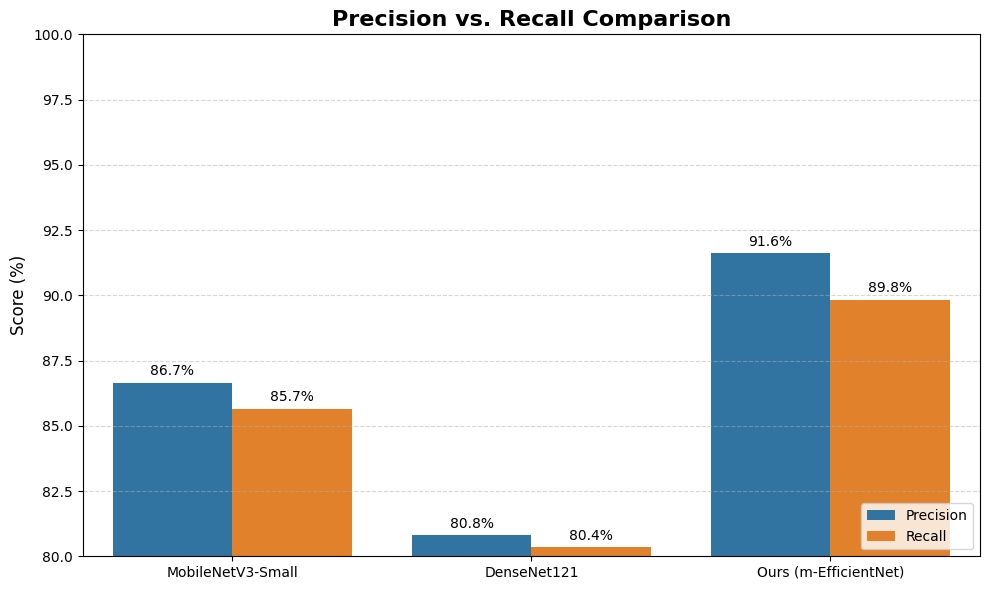

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Comparing Precision/Recall on: {device}")

pr_results = []

def get_pr_scores(model, name, loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    prec = precision_score(all_labels, all_preds, average='macro') * 100
    rec = recall_score(all_labels, all_preds, average='macro') * 100
    
    return prec, rec

try:
    print("Evaluating MobileNetV3...")
    mobilenet = models.mobilenet_v3_small(weights=None)
    mobilenet.classifier[3] = torch.nn.Linear(mobilenet.classifier[3].in_features, NUM_CLASSES)
    mobilenet.load_state_dict(comp_best_wts) # Loads from memory
    mobilenet.to(device)
    
    p, r = get_pr_scores(mobilenet, "MobileNetV3", test_loader)
    pr_results.append({'Model': 'MobileNetV3-Small', 'Metric': 'Precision', 'Score': p})
    pr_results.append({'Model': 'MobileNetV3-Small', 'Metric': 'Recall', 'Score': r})
except NameError:
    print("Skipping MobileNet (Weights not found in memory).")

try:
    print("Evaluating DenseNet121...")
    densenet = models.densenet121(weights=None)
    densenet.classifier = torch.nn.Linear(densenet.classifier.in_features, NUM_CLASSES)
    densenet.load_state_dict(dense_best_wts)
    densenet.to(device)
    
    p, r = get_pr_scores(densenet, "DenseNet121", test_loader)
    pr_results.append({'Model': 'DenseNet121', 'Metric': 'Precision', 'Score': p})
    pr_results.append({'Model': 'DenseNet121', 'Metric': 'Recall', 'Score': r})
except NameError:
    print("Skipping DenseNet (Weights not found in memory).")

try:
    print("Evaluating Our Model...")
    our_model = create_model(num_classes=NUM_CLASSES)
    our_model.load_state_dict(torch.load('m-EfficientNetB0-ECA_best.pth'))
    our_model.to(device)
    
    p, r = get_pr_scores(our_model, "Ours", test_loader)
    pr_results.append({'Model': 'Ours (m-EfficientNet)', 'Metric': 'Precision', 'Score': p})
    pr_results.append({'Model': 'Ours (m-EfficientNet)', 'Metric': 'Recall', 'Score': r})
except FileNotFoundError:
    print("Skipping Our Model (File not found).")

if pr_results:
    df = pd.DataFrame(pr_results)
    
    print("\n--- Detailed Precision vs Recall ---")
    pivot_df = df.pivot(index='Model', columns='Metric', values='Score')
    print(pivot_df.round(2))

    plt.figure(figsize=(10, 6))
    
    ax = sns.barplot(data=df, x='Model', y='Score', hue='Metric', palette=['#1f77b4', '#ff7f0e'])
    
    plt.ylim(80, 100)
    plt.title('Precision vs. Recall Comparison', fontsize=16, fontweight='bold')
    plt.ylabel('Score (%)', fontsize=12)
    plt.xlabel('', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(title=None, loc='lower right')
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3)

    plt.tight_layout()
    plt.savefig('precision_recall_comparison.png')
    print("\nChart saved as 'precision_recall_comparison.png'")
    plt.show()
else:
    print("No models available to compare.")

Evaluating MobileNetV3...
Evaluating DenseNet121...


C:\Users\Swastik kumar\AppData\Local\Temp\ipykernel_4888\2716122422.py:63: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  our_model.load_state_dict(torch.load('m-EfficientNet

Evaluating m-EfficientNet...

=== FINAL COMPARISON TABLE ===
         Model  Accuracy  F1-Score  Precision  Recall
   MobileNetV3     87.77     85.95      86.65   85.66
   DenseNet121     82.37     79.25      80.82   80.36
m-EfficientNet     91.94     90.51      91.61   89.84

Chart saved as 'comprehensive_comparison_chart.png'


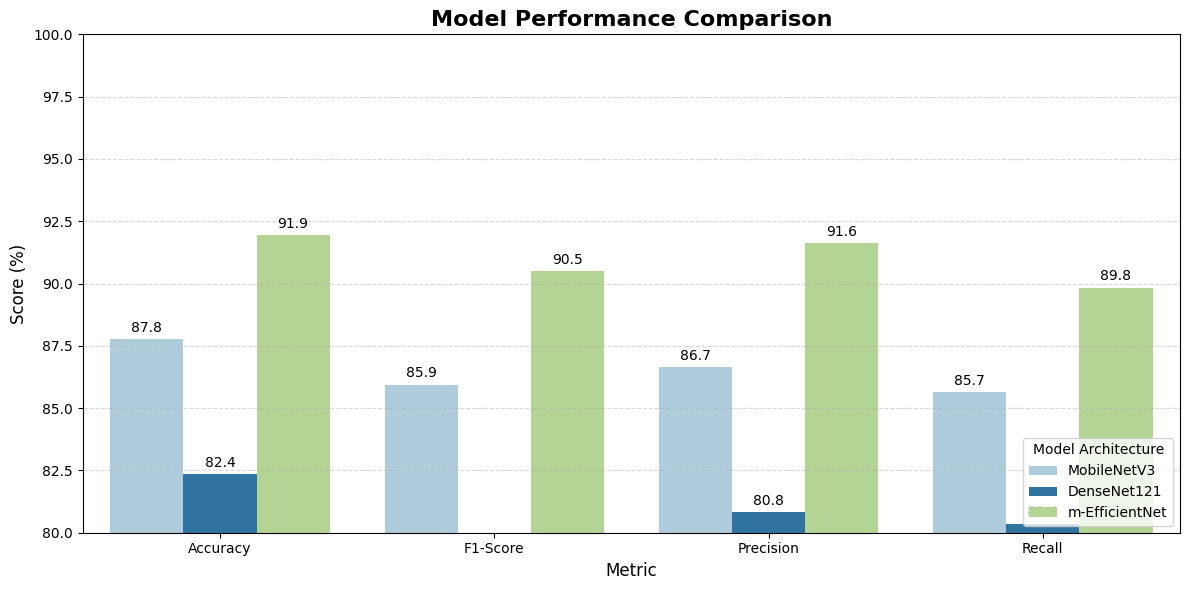

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

all_results = []

def evaluate_full_metrics(model, model_name):
    model.eval()
    all_preds = []
    all_labels = []
    
    print(f"Evaluating {model_name}...")
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    acc = accuracy_score(all_labels, all_preds) * 100
    prec = precision_score(all_labels, all_preds, average='macro') * 100
    rec = recall_score(all_labels, all_preds, average='macro') * 100
    f1 = f1_score(all_labels, all_preds, average='macro') * 100
    
    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    }


try:
    mobilenet = models.mobilenet_v3_small(weights=None)
    mobilenet.classifier[3] = torch.nn.Linear(mobilenet.classifier[3].in_features, NUM_CLASSES)
    mobilenet.load_state_dict(comp_best_wts) # Load from memory
    mobilenet.to(device)
    all_results.append(evaluate_full_metrics(mobilenet, "MobileNetV3"))
except NameError:
    print("Skipping MobileNet (Weights not in memory). Run PART 10 first.")

try:
    densenet = models.densenet121(weights=None)
    densenet.classifier = torch.nn.Linear(densenet.classifier.in_features, NUM_CLASSES)
    densenet.load_state_dict(dense_best_wts) # Load from memory
    densenet.to(device)
    all_results.append(evaluate_full_metrics(densenet, "DenseNet121"))
except NameError:
    print("Skipping DenseNet (Weights not in memory). Run PART 12 first.")

try:
    our_model = create_model(num_classes=NUM_CLASSES)
    our_model.load_state_dict(torch.load('m-EfficientNetB0-ECA_best.pth'))
    our_model.to(device)
    all_results.append(evaluate_full_metrics(our_model, "m-EfficientNet"))
except FileNotFoundError:
    print("Skipping Our Model (File not found).")


if all_results:
    df_results = pd.DataFrame(all_results)
    
    df_results = df_results[['Model', 'Accuracy', 'F1-Score', 'Precision', 'Recall']]
    
    print("\n=== FINAL COMPARISON TABLE ===")
    print(df_results.round(2).to_string(index=False))

    df_melted = df_results.melt(id_vars="Model", var_name="Metric", value_name="Score")

    plt.figure(figsize=(12, 6))
    
    custom_palette = sns.color_palette("Paired", n_colors=3)
    
    ax = sns.barplot(
        data=df_melted, 
        x="Metric", 
        y="Score", 
        hue="Model", 
        palette=custom_palette
    )

    plt.title("Model Performance Comparison", fontsize=16, fontweight='bold')
    plt.ylim(80, 100)
    plt.ylabel("Score (%)", fontsize=12)
    plt.xlabel("Metric", fontsize=12)
    plt.legend(title="Model Architecture", loc='lower right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=3, fontsize=10)

    plt.tight_layout()
    plt.savefig('comprehensive_comparison_chart.png', dpi=300)
    print("\nChart saved as 'comprehensive_comparison_chart.png'")
    plt.show()

else:
    print("\nNo models were evaluated. Please check if previous training cells were run.")

In [24]:
def print_model_report(model, model_name, loader):
    model.eval()
    model.to(device)
    
    all_preds = []
    all_labels = []
    total_images = 0
    
    if device.type == 'cuda': torch.cuda.synchronize()
    start_time = time.time()
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            total_images += inputs.size(0)
            
    if device.type == 'cuda': torch.cuda.synchronize()
    end_time = time.time()
    
    total_time = end_time - start_time
    avg_time = total_time / total_images
    fps = 1.0 / avg_time
    
    acc = accuracy_score(all_labels, all_preds) * 100
    prec = precision_score(all_labels, all_preds, average='macro') * 100
    rec = recall_score(all_labels, all_preds, average='macro') * 100
    f1 = f1_score(all_labels, all_preds, average='macro') * 100
    
    print(f"========================================")
    print(f"MODEL: {model_name}")
    print(f"========================================")
    print(f"Accuracy:           {acc:.2f}%")
    print(f"Precision (Macro):  {prec:.2f}%")
    print(f"Recall (Macro):     {rec:.2f}%")
    print(f"F1-Score (Macro):   {f1:.2f}%")
    print("-" * 40)
    print(f"Total Inference Time: {total_time:.4f} seconds")
    print(f"Avg Inference Time:   {avg_time:.6f} seconds/image")
    print(f"FPS (Images/Sec):     {fps:.2f}")
    print("========================================\n")

Generating Final Results on: cuda



In [25]:
try:
    print("Processing MobileNetV3...")
    mobilenet = models.mobilenet_v3_small(weights=None)
    mobilenet.classifier[3] = torch.nn.Linear(mobilenet.classifier[3].in_features, NUM_CLASSES)
    
    mobilenet.load_state_dict(comp_best_wts)
    
    print_model_report(mobilenet, "MobileNetV3-Small", test_loader)

except NameError:
    print("Error: 'comp_best_wts' not found. Did you run the training code for MobileNet?")

Processing MobileNetV3...
MODEL: MobileNetV3-Small
Accuracy:           87.77%
Precision (Macro):  86.65%
Recall (Macro):     85.66%
F1-Score (Macro):   85.95%
----------------------------------------
Total Inference Time: 29.8359 seconds
Avg Inference Time:   0.028280 seconds/image
FPS (Images/Sec):     35.36



In [26]:
try:
    print("Processing DenseNet121...")
    densenet = models.densenet121(weights=None)
    densenet.classifier = torch.nn.Linear(densenet.classifier.in_features, NUM_CLASSES)
    
    densenet.load_state_dict(dense_best_wts)
    
    print_model_report(densenet, "DenseNet121", test_loader)

except NameError:
    print("Error: 'dense_best_wts' not found. Did you run the training code for DenseNet?")

Processing DenseNet121...
MODEL: DenseNet121
Accuracy:           82.37%
Precision (Macro):  80.82%
Recall (Macro):     80.36%
F1-Score (Macro):   79.25%
----------------------------------------
Total Inference Time: 27.7462 seconds
Avg Inference Time:   0.026300 seconds/image
FPS (Images/Sec):     38.02



In [29]:
class ECA(nn.Module):
    def __init__(self, in_channels, kernel_size=3):
        super(ECA, self).__init__()
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=kernel_size, padding=(kernel_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        y = self.gap(x).squeeze(-1).permute(0, 2, 1)
        y = self.conv(y).permute(0, 2, 1)
        y = self.sigmoid(y).unsqueeze(-1)
        return x * y.expand_as(x)

def replace_se_with_eca(module):
    for name, child in module.named_children():
        if isinstance(child, models.efficientnet.SqueezeExcitation):
            in_channels = child.fc1.in_channels
            setattr(module, name, ECA(in_channels=in_channels))
        elif len(list(child.children())) > 0:
            replace_se_with_eca(child)

def create_model_structure(num_classes=7):
    model = models.efficientnet_b0(weights=None)
    
    replace_se_with_eca(model)
                    
    model.features[6] = model.features[6][0]
    model.features[7] = nn.Identity()
    
    old_conv = model.features[8][0]
    model.features[8][0] = nn.Conv2d(
        192, 
        old_conv.out_channels, 
        old_conv.kernel_size, 
        old_conv.stride, 
        old_conv.padding, 
        bias=(old_conv.bias is not None)
    )
    
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(model.classifier[1].in_features, num_classes)
    )
    return model

try:
    print("m-EfficientNet + ECA...")
    our_model = create_model_structure(num_classes=7)
    
    our_model.load_state_dict(torch.load('m-EfficientNetB0-ECA_best.pth'))

    print_model_report(our_model, "m-EfficientNet + ECA", test_loader)

except FileNotFoundError:
    print("Error: 'm-EfficientNetB0-ECA_best.pth' not found.")

m-EfficientNet + ECA...


C:\Users\Swastik kumar\AppData\Local\Temp\ipykernel_4888\2636426122.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  our_model.load_state_dict(torch.load('m-EfficientNet

MODEL: m-EfficientNet + ECA
Accuracy:           91.94%
Precision (Macro):  91.61%
Recall (Macro):     89.84%
F1-Score (Macro):   90.51%
----------------------------------------
Total Inference Time: 22.2628 seconds
Avg Inference Time:   0.021102 seconds/image
FPS (Images/Sec):     47.39



Evaluating MobileNetV3...
Evaluating DenseNet121...


C:\Users\Swastik kumar\AppData\Local\Temp\ipykernel_4888\2716122422.py:63: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  our_model.load_state_dict(torch.load('m-EfficientNet

Evaluating m-EfficientNet...

=== FINAL COMPARISON TABLE ===
         Model  Accuracy  F1-Score  Precision  Recall
   MobileNetV3     87.77     85.95      86.65   85.66
   DenseNet121     82.37     79.25      80.82   80.36
m-EfficientNet     91.94     90.51      91.61   89.84

Chart saved as 'comprehensive_comparison_chart.png'


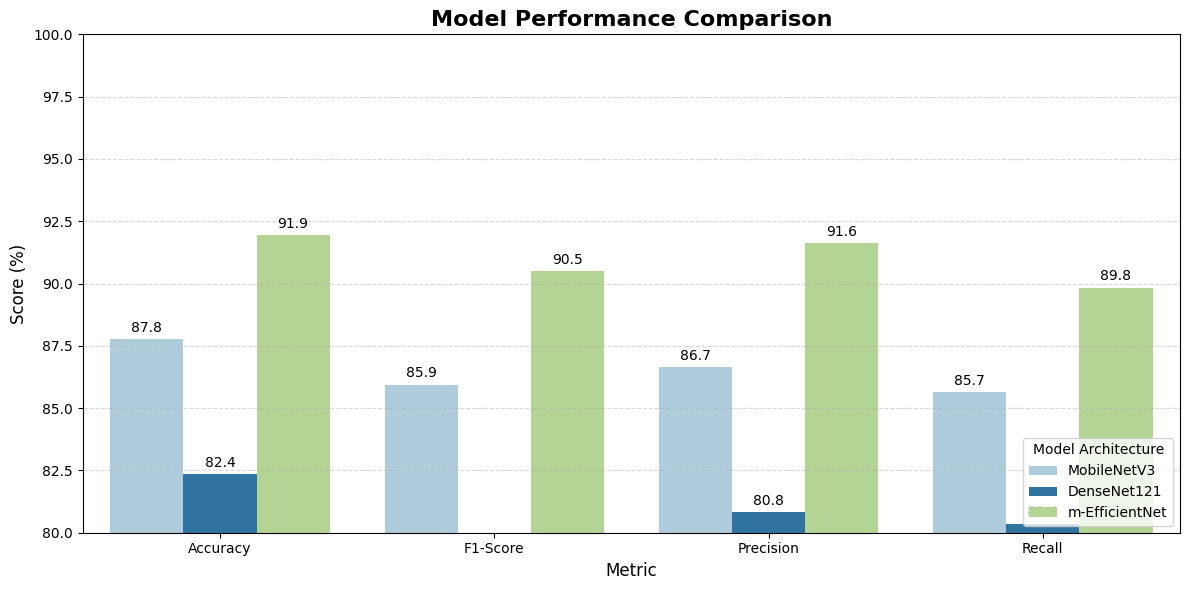

In [30]:
all_results = []

def evaluate_full_metrics(model, model_name):
    model.eval()
    all_preds = []
    all_labels = []
    
    print(f"Evaluating {model_name}...")
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    acc = accuracy_score(all_labels, all_preds) * 100
    prec = precision_score(all_labels, all_preds, average='macro') * 100
    rec = recall_score(all_labels, all_preds, average='macro') * 100
    f1 = f1_score(all_labels, all_preds, average='macro') * 100
    
    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    }


try:
    mobilenet = models.mobilenet_v3_small(weights=None)
    mobilenet.classifier[3] = torch.nn.Linear(mobilenet.classifier[3].in_features, NUM_CLASSES)
    mobilenet.load_state_dict(comp_best_wts) # Load from memory
    mobilenet.to(device)
    all_results.append(evaluate_full_metrics(mobilenet, "MobileNetV3"))
except NameError:
    print("Skipping MobileNet (Weights not in memory). Run PART 10 first.")

try:
    densenet = models.densenet121(weights=None)
    densenet.classifier = torch.nn.Linear(densenet.classifier.in_features, NUM_CLASSES)
    densenet.load_state_dict(dense_best_wts) # Load from memory
    densenet.to(device)
    all_results.append(evaluate_full_metrics(densenet, "DenseNet121"))
except NameError:
    print("Skipping DenseNet (Weights not in memory). Run PART 12 first.")

try:
    our_model = create_model(num_classes=NUM_CLASSES)
    our_model.load_state_dict(torch.load('m-EfficientNetB0-ECA_best.pth'))
    our_model.to(device)
    all_results.append(evaluate_full_metrics(our_model, "m-EfficientNet"))
except FileNotFoundError:
    print("Skipping Our Model (File not found).")

if all_results:
    df_results = pd.DataFrame(all_results)
    
    df_results = df_results[['Model', 'Accuracy', 'F1-Score', 'Precision', 'Recall']]
    
    print("\n=== FINAL COMPARISON TABLE ===")
    print(df_results.round(2).to_string(index=False))

    df_melted = df_results.melt(id_vars="Model", var_name="Metric", value_name="Score")

    plt.figure(figsize=(12, 6))
    
    custom_palette = sns.color_palette("Paired", n_colors=3)
    
    ax = sns.barplot(
        data=df_melted, 
        x="Metric", 
        y="Score", 
        hue="Model", 
        palette=custom_palette
    )

    plt.title("Model Performance Comparison", fontsize=16, fontweight='bold')
    plt.ylim(80, 100)
    plt.ylabel("Score (%)", fontsize=12)
    plt.xlabel("Metric", fontsize=12)
    plt.legend(title="Model Architecture", loc='lower right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=3, fontsize=10)

    plt.tight_layout()
    plt.savefig('comprehensive_comparison_chart.png', dpi=300)
    print("\nChart saved as 'comprehensive_comparison_chart.png'")
    plt.show()

else:
    print("\nNo models were evaluated. Please check if previous training cells were run.")

In [32]:
!pip install torchsummary
from torchsummary import summary

print("Generating Model Summaries...\n")

print("\n" + "="*60)
print("MODEL 1: MobileNetV3-Small (Benchmark)")
print("="*60)
try:
    model1 = models.mobilenet_v3_small(weights=None)
    model1.classifier[3] = nn.Linear(model1.classifier[3].in_features, 7)
    model1.to(device)
    summary(model1, input_size=(3, 256, 256))
except Exception as e:
    print("Error summary for MobileNet:", e)

print("\n" + "="*60)
print("MODEL 2: DenseNet121 (High-Accuracy Benchmark)")
print("="*60)
try:
    model2 = models.densenet121(weights=None)
    model2.classifier = nn.Linear(model2.classifier.in_features, 7)
    model2.to(device)
    summary(model2, input_size=(3, 256, 256))
except Exception as e:
    print("Error summary for DenseNet:", e)

print("\n" + "="*60)
print("MODEL 3: Proposed (m-EfficientNetB0 + ECA)")
print("="*60)
try:
    model3 = create_model(num_classes=7)

    model3.to(device)
    summary(model3, input_size=(3, 256, 256))
except NameError:
    print("Error: 'create_model' function not defined. Please run the model definition cell first.")
except Exception as e:
    print("Error summary for Proposed Model:", e)

Generating Model Summaries...


MODEL 1: MobileNetV3-Small (Benchmark)



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 128]             432
       BatchNorm2d-2         [-1, 16, 128, 128]              32
         Hardswish-3         [-1, 16, 128, 128]               0
            Conv2d-4           [-1, 16, 64, 64]             144
       BatchNorm2d-5           [-1, 16, 64, 64]              32
              ReLU-6           [-1, 16, 64, 64]               0
 AdaptiveAvgPool2d-7             [-1, 16, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             136
              ReLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 16, 1, 1]             144
      Hardsigmoid-11             [-1, 16, 1, 1]               0
SqueezeExcitation-12           [-1, 16, 64, 64]               0
           Conv2d-13           [-1, 16, 64, 64]             256
      BatchNorm2d-14           [-1, 16,

In [34]:
%pip install torchinfo
from torchinfo import summary

print("Generating Keras-Style Model Summaries...\n")

def print_header(name):
    print("\n" + "="*60)
    print(f"MODEL: {name}")
    print("="*60)


print_header("MobileNetV3-Small")
model1 = models.mobilenet_v3_small(weights=None)
model1.classifier[3] = nn.Linear(model1.classifier[3].in_features, 7)

summary(model1, 
        input_size=(1, 3, 256, 256), 
        col_names=["output_size", "num_params"], 
        depth=3)

print_header("DenseNet121")
model2 = models.densenet121(weights=None)
model2.classifier = nn.Linear(model2.classifier.in_features, 7)

summary(model2, 
        input_size=(1, 3, 256, 256), 
        col_names=["output_size", "num_params"], 
        depth=2)

print_header("Ours (m-EfficientNetB0 + ECA)")

class ECA(nn.Module):
    def __init__(self, in_channels, kernel_size=3):
        super(ECA, self).__init__()
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=kernel_size, padding=(kernel_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        y = self.gap(x).squeeze(-1).permute(0, 2, 1)
        y = self.conv(y).permute(0, 2, 1)
        y = self.sigmoid(y).unsqueeze(-1)
        return x * y.expand_as(x)

def create_model_structure(num_classes=7):
    model = models.efficientnet_b0(weights=None)
    for name, child in model.named_children():
        if isinstance(child, models.efficientnet.SqueezeExcitation):
            setattr(model, name, ECA(child.fc1.in_channels))
        elif len(list(child.children())) > 0:
            for n, c in child.named_children():
                if isinstance(c, models.efficientnet.SqueezeExcitation):
                    setattr(child, n, ECA(c.fc1.in_channels))
    model.features[6] = model.features[6][0]
    model.features[7] = nn.Identity()
    old_conv = model.features[8][0]
    model.features[8][0] = nn.Conv2d(192, old_conv.out_channels, old_conv.kernel_size, old_conv.stride, old_conv.padding, bias=(old_conv.bias is not None))
    model.classifier = nn.Sequential(nn.Dropout(0.2), nn.Linear(model.classifier[1].in_features, num_classes))
    return model

model3 = create_model_structure(num_classes=7)

summary(model3, 
        input_size=(1, 3, 256, 256), 
        col_names=["output_size", "num_params"], 
        depth=3)

Note: you may need to restart the kernel to use updated packages.
Generating Keras-Style Model Summaries...


MODEL: MobileNetV3-Small



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



MODEL: DenseNet121

MODEL: Ours (m-EfficientNetB0 + ECA)


Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [1, 7]                    --
├─Sequential: 1-1                                       [1, 1280, 8, 8]           --
│    └─Conv2dNormActivation: 2-1                        [1, 32, 128, 128]         --
│    │    └─Conv2d: 3-1                                 [1, 32, 128, 128]         864
│    │    └─BatchNorm2d: 3-2                            [1, 32, 128, 128]         64
│    │    └─SiLU: 3-3                                   [1, 32, 128, 128]         --
│    └─Sequential: 2-2                                  [1, 16, 128, 128]         --
│    │    └─MBConv: 3-4                                 [1, 16, 128, 128]         1,448
│    └─Sequential: 2-3                                  [1, 24, 64, 64]           --
│    │    └─MBConv: 3-5                                 [1, 24, 64, 64]           6,004
│    │    └─MBConv: 3-6                              

In [5]:
print("\n" + "="*60)
print("MODEL 2: DenseNet121")
print("="*60)

m2 = models.densenet121(weights=None)
m2.classifier = nn.Linear(m2.classifier.in_features, 7)

summary(m2,
        input_size=(1, 3, 256, 256), 
        col_names=["output_size", "num_params"], 
        depth=1)


MODEL 2: DenseNet121


Layer (type:depth-idx)                   Output Shape              Param #
DenseNet                                 [1, 7]                    --
├─Sequential: 1-1                        [1, 1024, 8, 8]           6,953,856
├─Linear: 1-2                            [1, 7]                    7,175
Total params: 6,961,031
Trainable params: 6,961,031
Non-trainable params: 0
Total mult-adds (G): 3.70
Input size (MB): 0.79
Forward/backward pass size (MB): 235.80
Params size (MB): 27.84
Estimated Total Size (MB): 264.43

In [6]:
print("\n" + "="*60)
print("m-EfficientNetB0 + ECA")
print("="*60)

class ECA(nn.Module):
    def __init__(self, in_channels, kernel_size=3):
        super(ECA, self).__init__()
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=kernel_size, padding=(kernel_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        y = self.gap(x).squeeze(-1).permute(0, 2, 1)
        y = self.conv(y).permute(0, 2, 1)
        y = self.sigmoid(y).unsqueeze(-1)
        return x * y.expand_as(x)

def create_model_structure(num_classes=7):
    model = models.efficientnet_b0(weights=None)
    
    for name, child in model.named_children():
        if isinstance(child, models.efficientnet.SqueezeExcitation):
            setattr(model, name, ECA(child.fc1.in_channels))
        elif len(list(child.children())) > 0:
            for n, c in child.named_children():
                if isinstance(c, models.efficientnet.SqueezeExcitation):
                    setattr(child, n, ECA(c.fc1.in_channels))
                    
    model.features[6] = model.features[6][0]
    model.features[7] = nn.Identity()
    
    old_conv = model.features[8][0]
    model.features[8][0] = nn.Conv2d(192, old_conv.out_channels, old_conv.kernel_size, old_conv.stride, old_conv.padding, bias=(old_conv.bias is not None))
    
    model.classifier = nn.Sequential(nn.Dropout(0.2), nn.Linear(model.classifier[1].in_features, num_classes))
    return model

m3 = create_model_structure(num_classes=7)

summary(m3,
        input_size=(1, 3, 256, 256), 
        col_names=["output_size", "num_params"], 
        depth=2)


m-EfficientNetB0 + ECA


Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [1, 7]                    --
├─Sequential: 1-1                                       [1, 1280, 8, 8]           --
│    └─Conv2dNormActivation: 2-1                        [1, 32, 128, 128]         928
│    └─Sequential: 2-2                                  [1, 16, 128, 128]         1,448
│    └─Sequential: 2-3                                  [1, 24, 64, 64]           16,714
│    └─Sequential: 2-4                                  [1, 40, 32, 32]           46,640
│    └─Sequential: 2-5                                  [1, 80, 16, 16]           242,930
│    └─Sequential: 2-6                                  [1, 112, 16, 16]          543,148
│    └─MBConv: 2-7                                      [1, 192, 8, 8]            262,492
│    └─Identity: 2-8                                    [1, 192, 8, 8]            --
│    └─Conv2dNormActivation: 2-9 

In [11]:
print("\n" + "="*60)
print("MODEL: MobileNetV3-Small")
print("="*60)

model = models.mobilenet_v3_small(weights=None)

model.classifier[3] = nn.Linear(model.classifier[3].in_features, 7)

summary(model, 
        input_size=(1, 3, 256, 256), 
        col_names=["output_size", "num_params", "mult_adds"], 
        depth=3)


MODEL: MobileNetV3-Small


Layer (type:depth-idx)                             Output Shape              Param #                   Mult-Adds
MobileNetV3                                        [1, 7]                    --                        --
├─Sequential: 1-1                                  [1, 576, 8, 8]            --                        --
│    └─Conv2dNormActivation: 2-1                   [1, 16, 128, 128]         --                        --
│    │    └─Conv2d: 3-1                            [1, 16, 128, 128]         432                       7,077,888
│    │    └─BatchNorm2d: 3-2                       [1, 16, 128, 128]         32                        32
│    │    └─Hardswish: 3-3                         [1, 16, 128, 128]         --                        --
│    └─InvertedResidual: 2-2                       [1, 16, 64, 64]           --                        --
│    │    └─Sequential: 3-4                        [1, 16, 64, 64]           744                       1,638,744
│    └─InvertedResidual: 

Generating Dark Mode Summary for MobileNetV3...

Success! Dark Mode summary saved as 'mobilenet_summary_dark.png'


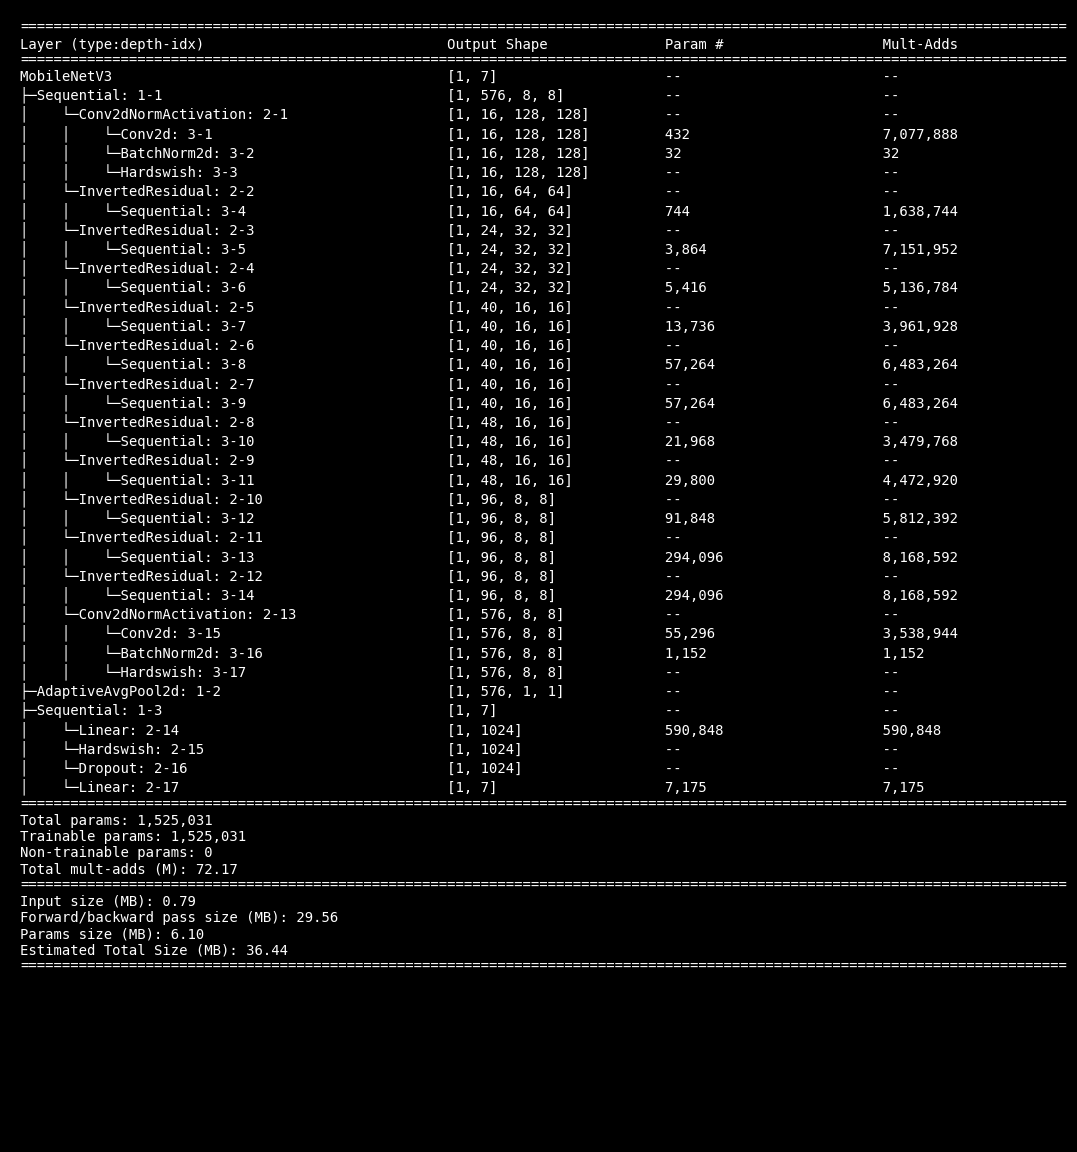

In [18]:

model = models.mobilenet_v3_small(weights=None)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, 7)

model_stats = summary(model,
                      input_size=(1, 3, 256, 256), 
                      col_names=["output_size", "num_params", "mult_adds"], 
                      depth=3,
                      verbose=0) 
summary_text = str(model_stats)

fig = plt.figure(figsize=(12, 12), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.text(0.01, 0.99, summary_text,
         fontsize=10, 
         family='monospace', 
         verticalalignment='top',
         color='white')

plt.axis('off')
plt.tight_layout()

save_path = "mobilenet_summary_dark.png"

plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='black', transparent=False)

print(f"\nSuccess! Dark Mode summary saved as '{save_path}'")
plt.show()